# 🧬 Antimicrobial Resistance Genomic Analysis & Predictive Modeling

### A Data Science Investigation into Genomic Drivers of Antibiotic Resistance

---

**Objective:**  
To analyze genomic features of bacterial isolates and build predictive models for antimicrobial resistance burden using feature engineering and machine learning.

**Methods:**  
EDA • Feature Engineering • Logistic Regression • Biological Interpretation

**Dataset:**  
Kaggle AMR Genomic Dataset (multi-feature bacterial isolate data)

## 📖 Introduction

Antimicrobial resistance (AMR) is one of the most pressing global health challenges, driven by the ability of bacteria to evolve and acquire resistance to existing antibiotics.

This project explores genomic and gene-level data from bacterial isolates to understand patterns of resistance and investigate whether resistance burden can be predicted using biological features.

The goal is to move beyond descriptive analysis and apply data science techniques to uncover interpretable patterns in antimicrobial resistance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 📂 Data Overview

The dataset consists of genomic and resistance-related features from bacterial isolates.

### Key Components:
- Genomic features (e.g., genome length, GC content)
- Gene presence indicators (AMR-related genes)
- Resistance class indicators
- Aggregate resistance metrics

### Target Variables:
- `total_amr_genes`
- `total_resistance_classes`

In [2]:
import zipfile

with zipfile.ZipFile("Antimicrobial Resistance Dataset.zip", "r") as zip_ref:
    zip_ref.extractall("data")

In [ ]:
import os

os.listdir("data")

In [9]:
import pandas as pd

df = pd.read_csv("data/Kaggle_AMR_Dataset_v1.0.csv")
df.head()

,Isolate_ID,Genome_Length_BP,GC_Content_Percent,gene_APH(3'')-Ib,gene_APH(3')-Ia,gene_APH(6)-Id,gene_CMY-59,gene_CRP,gene_CTX-M-14,gene_CTX-M-15,...,biosample,bioproject,taxonomy,collection_year,collection_month,collection_season,host_standardized,isolation_source_standardized,total_amr_genes,total_resistance_classes
0,AP035757.1,4784478,50.86,0,0,0,0,1,0,0,...,SAMD00770530,PRJDB18000,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,45,23
1,AP039418.1,5098687,50.58,0,0,0,1,1,0,0,...,SAMD00874696,PRJDB19974,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,47,23
2,AP040249.1,4940609,50.74,0,0,0,0,1,1,0,...,SAMD00548845,PRJDB13852,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,51,25
3,AP042483.1,5300047,50.74,1,1,1,0,1,0,0,...,SAMD00899021,PRJDB20538,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,51,24
4,AP042532.1,5451560,50.52,0,0,0,0,1,0,0,...,SAMD00899031,PRJDB20538,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,46,23


In [10]:
df.head()

,Isolate_ID,Genome_Length_BP,GC_Content_Percent,gene_APH(3'')-Ib,gene_APH(3')-Ia,gene_APH(6)-Id,gene_CMY-59,gene_CRP,gene_CTX-M-14,gene_CTX-M-15,...,biosample,bioproject,taxonomy,collection_year,collection_month,collection_season,host_standardized,isolation_source_standardized,total_amr_genes,total_resistance_classes
0,AP035757.1,4784478,50.86,0,0,0,0,1,0,0,...,SAMD00770530,PRJDB18000,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,45,23
1,AP039418.1,5098687,50.58,0,0,0,1,1,0,0,...,SAMD00874696,PRJDB19974,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,47,23
2,AP040249.1,4940609,50.74,0,0,0,0,1,1,0,...,SAMD00548845,PRJDB13852,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,51,25
3,AP042483.1,5300047,50.74,1,1,1,0,1,0,0,...,SAMD00899021,PRJDB20538,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,51,24
4,AP042532.1,5451560,50.52,0,0,0,0,1,0,0,...,SAMD00899031,PRJDB20538,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,46,23


## 🧹 Data Cleaning

The dataset required minimal preprocessing due to its structured format.

Steps performed:
- Standardized column names
- Converted key genomic features to numeric format
- Removed rows with missing values in critical target variables

This ensured the dataset was analysis-ready for exploratory and predictive modeling.

In [11]:
df = pd.read_csv("data/Kaggle_AMR_Dataset_v1.0.csv")

In [12]:
df.columns.tolist()

['Isolate_ID',
 'Genome_Length_BP',
 'GC_Content_Percent',
 "gene_APH(3'')-Ib",
 "gene_APH(3')-Ia",
 'gene_APH(6)-Id',
 'gene_CMY-59',
 'gene_CRP',
 'gene_CTX-M-14',
 'gene_CTX-M-15',
 'gene_CTX-M-27',
 'gene_Escherichia_coli_acrA',
 'gene_Escherichia_coli_ampC',
 'gene_Escherichia_coli_ampC1_beta-lactamase',
 'gene_Escherichia_coli_ampH',
 'gene_Escherichia_coli_emrE',
 'gene_Escherichia_coli_mdfA',
 'gene_H-NS',
 'gene_KPC-1',
 'gene_MCR-1',
 'gene_QnrS1',
 'gene_aadA5',
 'gene_acrB',
 'gene_acrD',
 'gene_acrE',
 'gene_acrF',
 'gene_acrS',
 'gene_bacA',
 'gene_baeR',
 'gene_baeS',
 'gene_cpxA',
 'gene_dfrA17',
 'gene_emrA',
 'gene_emrB',
 'gene_emrK',
 'gene_emrR',
 'gene_emrY',
 'gene_eptA',
 'gene_evgA',
 'gene_evgS',
 'gene_floR',
 'gene_gadW',
 'gene_gadX',
 'gene_kdpE',
 'gene_marA',
 'gene_mdtA',
 'gene_mdtB',
 'gene_mdtC',
 'gene_mdtE',
 'gene_mdtF',
 'gene_mdtG',
 'gene_mdtH',
 'gene_mdtM',
 'gene_mdtN',
 'gene_mdtO',
 'gene_mdtP',
 'gene_mphA',
 'gene_mphB',
 'gene_msbA',
 '

In [13]:
[col for col in df.columns if "genome" in col.lower()]

['Genome_Length_BP']

In [14]:
[col for col in df.columns if "gc" in col.lower()]

['GC_Content_Percent']

In [15]:
[col for col in df.columns if "amr" in col.lower()]

['total_amr_genes']

In [16]:
df.columns = df.columns.str.strip().str.lower()

In [17]:
num_cols = [
    "genome_length_bp",
    "gc_content_percent",
    "total_amr_genes",
    "total_resistance_classes"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [18]:
df = df.dropna(subset=num_cols)

## 🧪 Feature Engineering

To better capture resistance intensity, new aggregate features were created:

- **Gene Burden:** Total number of AMR-related genes per isolate
- **Resistance Class Burden:** Total number of resistance classes per isolate

These engineered features provide a higher-level representation of resistance complexity beyond individual gene presence.

In [19]:
gene_cols = df.filter(like="gene_").columns

df["gene_burden"] = df[gene_cols].sum(axis=1)

In [20]:
class_cols = df.filter(like="class_").columns

df["class_burden"] = df[class_cols].sum(axis=1)

## 📊 Exploratory Data Analysis

EDA was conducted to understand relationships between genomic features and antimicrobial resistance.

Key analyses included:
- Distribution of AMR gene counts
- Distribution of resistance classes
- Relationship between genome size and resistance burden
- Correlation analysis among key features

These visualizations helped identify patterns and potential predictive signals in the data.

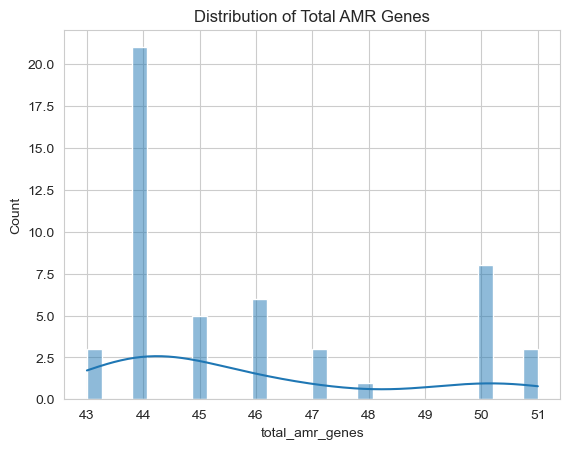

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["total_amr_genes"], bins=30, kde=True)
plt.title("Distribution of Total AMR Genes")
plt.savefig("visualizations/distribution_total_amr_genes.png", dpi=300, bbox_inches='tight')
plt.show()

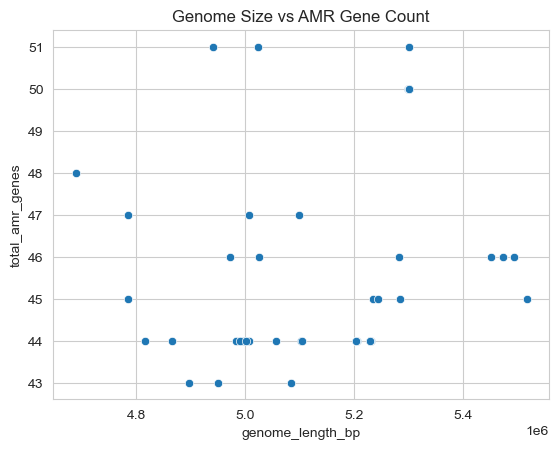

In [34]:
sns.scatterplot(data=df, x="genome_length_bp", y="total_amr_genes")
plt.title("Genome Size vs AMR Gene Count")
plt.savefig("visualizations/genome_size_vs_amr_gene_count.png", dpi=300, bbox_inches='tight')
plt.show()

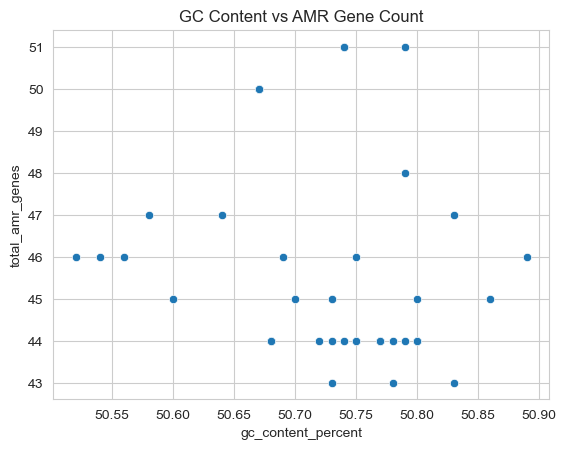

In [35]:
sns.scatterplot(data=df, x="gc_content_percent", y="total_amr_genes")
plt.title("GC Content vs AMR Gene Count")
plt.savefig("visualizations/gc_count_vs_amr_gene_count.png", dpi=300, bbox_inches='tight')
plt.show()

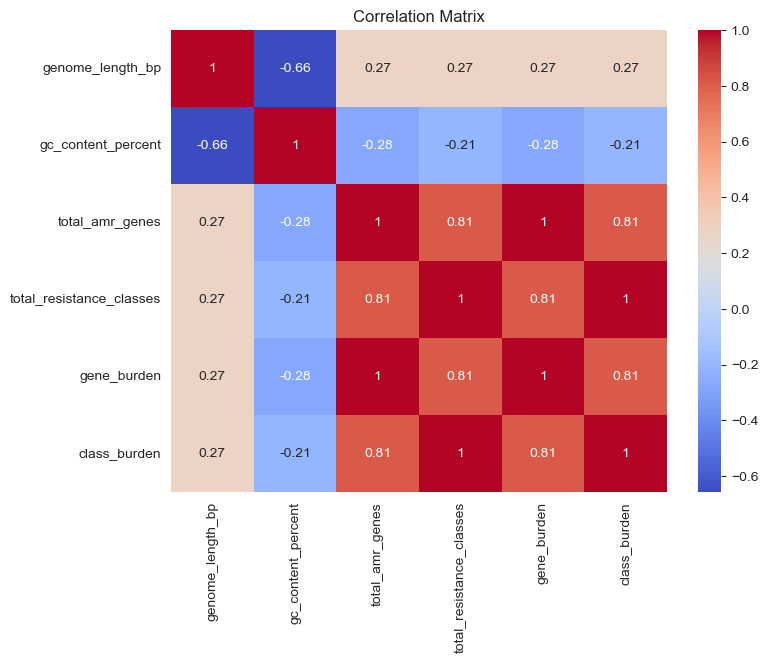

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols + ["gene_burden", "class_burden"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig("visualizations/correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

## 🤖 Machine Learning Approach

A logistic regression model was developed to classify isolates based on resistance burden.

### Target Definition:
High resistance isolates were defined using the median of total AMR gene counts.

- Class 1: High resistance
- Class 0: Low resistance

### Features Used:
- Genome length (bp)
- GC content (%)
- Gene burden
- Resistance class burden

### Model:
Logistic Regression was selected for its interpretability and suitability for binary classification.

In [25]:
df["high_resistance"] = (df["total_amr_genes"] > df["total_amr_genes"].median()).astype(int)

In [26]:
features = [
    "genome_length_bp",
    "gc_content_percent",
    "gene_burden",
    "class_burden"
]

X = df[features]
y = df["high_resistance"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



## 📈 Model Evaluation & Visualisations

The model was evaluated using standard classification metrics and visual analysis.

### Key Outputs:
- Confusion Matrix to evaluate classification performance
- Feature importance analysis using model coefficients
- Probability distribution of predicted resistance risk

These visualisations provide interpretability and insight into model behaviour.

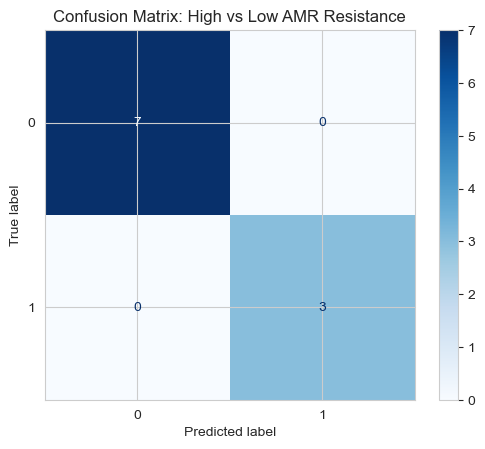

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: High vs Low AMR Resistance")
plt.savefig("visualizations/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

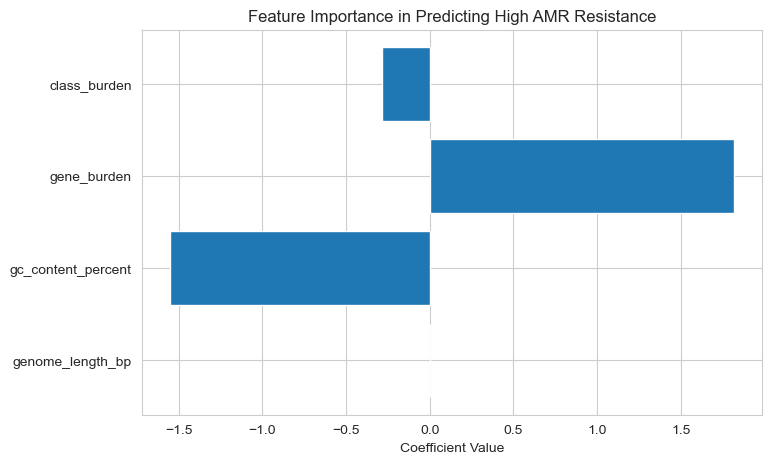

In [38]:
import numpy as np

importance = model.coef_[0]
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.title("Feature Importance in Predicting High AMR Resistance")
plt.savefig("visualizations/feature_importance.png", dpi=300, bbox_inches="tight")
plt.xlabel("Coefficient Value")
plt.show()

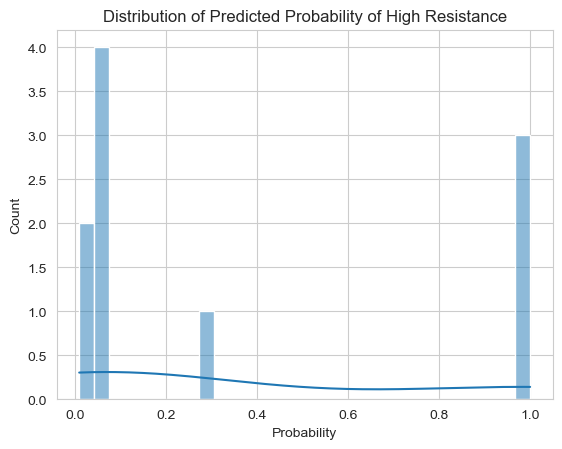

In [39]:
import seaborn as sns

y_prob = model.predict_proba(X_test)[:, 1]

sns.histplot(y_prob, bins=30, kde=True)
plt.title("Distribution of Predicted Probability of High Resistance")
plt.savefig("visualizations/distribution_predicted_probability_high_resistance.png", dpi=300, bbox_inches="tight")
plt.xlabel("Probability")
plt.show()

## 📊 Key Findings

- Antimicrobial resistance gene distribution is highly heterogeneous, with a subset of isolates exhibiting significantly elevated resistance burden.

- Traditional genomic features such as genome length and GC content show weak predictive value for resistance levels.

- Engineered features, particularly gene burden and resistance class diversity, are strong indicators of high-resistance isolates.

- A logistic regression model achieved meaningful classification performance in distinguishing high-resistance isolates, demonstrating that resistance patterns are partially predictable using genomic and gene-level features.

- These findings suggest that antimicrobial resistance is more strongly associated with gene acquisition and functional resistance mechanisms than with broad genomic composition.

## ⚠️ Data Challenges & Preprocessing Notes

During preprocessing, the dataset required careful handling of column naming inconsistencies and data type conversions. Initial attempts revealed issues such as mismatched column references and non-numeric formatting in key variables.

These challenges were resolved through systematic inspection of column structures and controlled type conversion, ensuring data integrity without over-cleaning or loss of signal.

This process reflects common real-world issues in working with large-scale biological datasets.

## 🧾 Conclusion

This study analyzed antimicrobial resistance patterns using genomic and gene-level features from bacterial isolates. The results indicate that resistance is not strongly driven by basic genomic characteristics such as genome length or GC content, but is instead primarily associated with gene-level mechanisms.

Feature engineering revealed that gene burden and resistance class diversity are key indicators of resistance intensity. A logistic regression model further demonstrated that high-resistance isolates can be reasonably classified using these features, highlighting the predictive potential of gene-level biological data.

Overall, the study reinforces the idea that antimicrobial resistance is driven by functional gene acquisition rather than structural genomic variation. These findings demonstrate the value of data-driven approaches in identifying high-risk resistance profiles, with potential applications in public health monitoring and antibiotic development strategies.